In [106]:
%cd /home/ytee/test/trade_bot/

from src.pattern.momentum import MOMENTUM 
from src.pattern.functions import get_barrier
import pandas as pd
import numpy as np
m= MOMENTUM()


/home/yteevm/.local/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/ytee/test/trade_bot


In [107]:
xx = m._get_barrier_preprocess('4h')
xx2=  xx[xx.trigger!=0]

In [109]:
sum1 = m.summary_by_window('4h')

In [115]:
sum1.columns

Index(['gap_min_cnt', 'gap_max_cnt', 'gap_min_mean', 'gap_max_mean',
       'gap_min_q25', 'gap_min_q50', 'gap_min_q75', 'gap_max_q25',
       'gap_max_q50', 'gap_max_q75', 'gap_cnt', 'gap_mean', 'gap_q25',
       'gap_q50', 'gap_q75'],
      dtype='object')

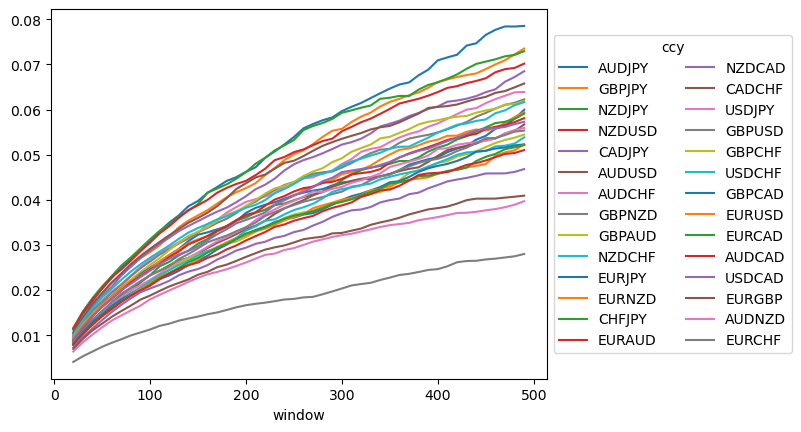

In [116]:
wide = sum1['gap_q25'].unstack('ccy')   # index = k, columns = ccy

# # Choose a sorting key: last available value per ccy
last_vals = wide.ffill().iloc[-1]          # forward-fill, then take the last row
order = last_vals.sort_values(ascending=False).index  # largest on top, smallest last (bottom)
ax = wide[order].plot(linewidth=1.5)
ax.legend(title='ccy', ncol=2, loc='center left', bbox_to_anchor=(1.0, 0.5))      

In [3]:
xx2.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'ccy', 'gap_max',
       'gap_min', 'gap_max_pct', 'gap_min_pct', 'window', 'year', 'gap_pct',
       'trigger', 'gap_q25', 'gap_q50', 'gap_q75'],
      dtype='object')

In [3]:
all_summary = m.main('4h')

100%|██████████| 288/288 [49:55<00:00, 10.40s/it] 


In [6]:

all_summary

,ccy,window,n_total,n_gt25,n_gt50,n_gt75,tp_gt25,tp_gt50,tp_gt75,none_gt25,...,sl_gt25,sl_gt50,sl_gt75,gt25,gt50,gt75,thresh,ratio,barrier_window,overlap
0,AUDCAD,20,6147,4608,3069,1534,0.451606,0.444119,0.431551,0.002387,...,0.546007,0.553926,0.568449,-0.094401,-0.109808,-0.136897,gap_q25,0.25,20,0
1,AUDCAD,30,4882,3660,2439,1220,0.448361,0.440344,0.428689,0.013661,...,0.537978,0.551046,0.569672,-0.089617,-0.110701,-0.140984,gap_q25,0.25,20,0
2,AUDCAD,40,4162,3121,2080,1041,0.444729,0.441827,0.434198,0.023070,...,0.532201,0.545673,0.560999,-0.087472,-0.103846,-0.126801,gap_q25,0.25,20,0
3,AUDCAD,50,3650,2737,1824,913,0.434417,0.428728,0.434830,0.044209,...,0.521374,0.542215,0.556407,-0.086957,-0.113487,-0.121577,gap_q25,0.25,20,0
4,AUDCAD,60,3345,2508,1672,837,0.416667,0.405502,0.408602,0.066188,...,0.517145,0.547249,0.569892,-0.100478,-0.141746,-0.161290,gap_q25,0.25,20,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387067,USDJPY,450,67,35,18,8,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,gap_q75,1.25,90,1
387068,USDJPY,460,67,37,18,8,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,gap_q75,1.25,90,1
387069,USDJPY,470,67,37,18,8,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,gap_q75,1.25,90,1
387070,USDJPY,480,66,37,18,7,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,gap_q75,1.25,90,1


In [8]:

all_summary.to_csv('momentum_all_summary.csv', index=False)

Compare state probability

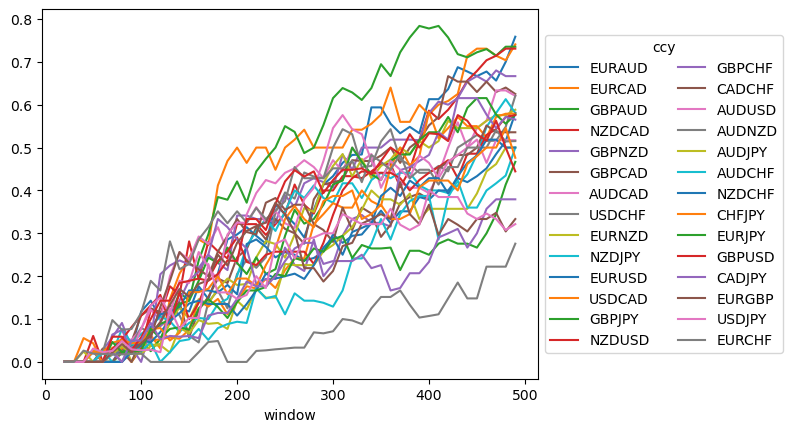

In [69]:
wide = summary2['none_gt75'].unstack('ccy')   # index = k, columns = ccy

# # Choose a sorting key: last available value per ccy
last_vals = wide.ffill().iloc[-1]          # forward-fill, then take the last row
order = last_vals.sort_values(ascending=False).index  # largest on top, smallest last (bottom)
ax = wide[order].plot(linewidth=1.5)
ax.legend(title='ccy', ncol=2, loc='center left', bbox_to_anchor=(1.0, 0.5))             # tweak layout as you like


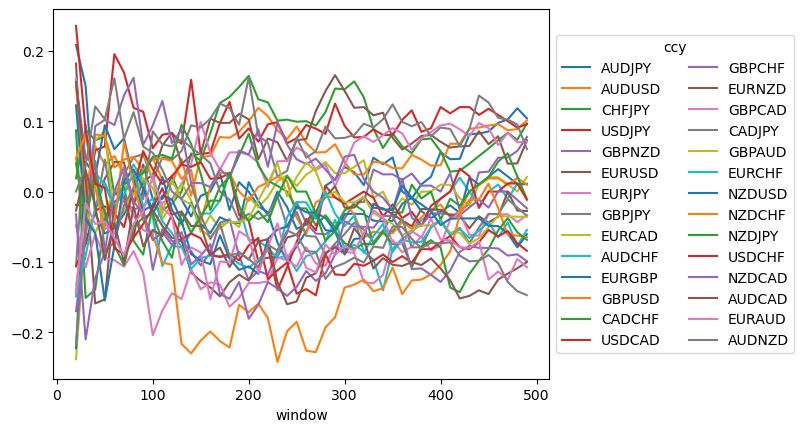

In [70]:
wide = summary2['gt25'].unstack('ccy')   # index = k, columns = ccy

# # Choose a sorting key: last available value per ccy
last_vals = wide.ffill().iloc[-1]          # forward-fill, then take the last row
order = last_vals.sort_values(ascending=False).index  # largest on top, smallest last (bottom)
ax = wide[order].plot(linewidth=1.5)
ax.legend(title='ccy', ncol=2, loc='center left', bbox_to_anchor=(1.0, 0.5))             # tweak layout as you like


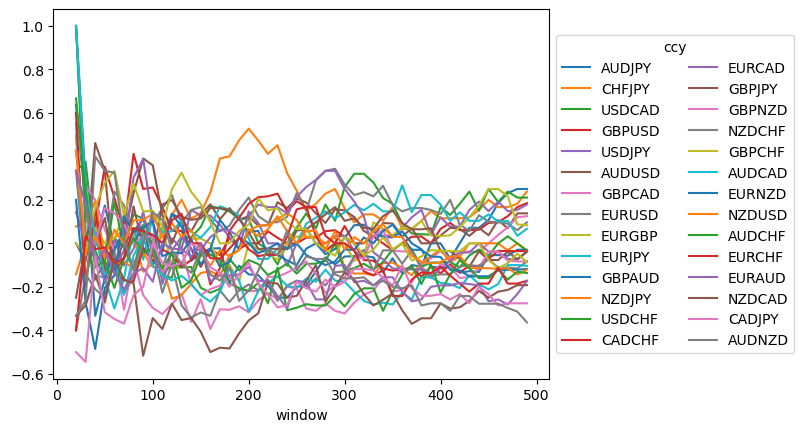

In [71]:
wide = summary2['gt75'].unstack('ccy')   # index = k, columns = ccy

# # Choose a sorting key: last available value per ccy
last_vals = wide.ffill().iloc[-1]          # forward-fill, then take the last row
order = last_vals.sort_values(ascending=False).index  # largest on top, smallest last (bottom)
ax = wide[order].plot(linewidth=1.5)
ax.legend(title='ccy', ncol=2, loc='center left', bbox_to_anchor=(1.0, 0.5))             # tweak layout as you like


In [ ]:
wide = summary['gap_cnt'].unstack('ccy')   # index = k, columns = ccy

# # Choose a sorting key: last available value per ccy
last_vals = wide.ffill().iloc[-1]          # forward-fill, then take the last row
order = last_vals.sort_values(ascending=False).index  # largest on top, smallest last (bottom)
ax = wide[order].plot(linewidth=1.5)
ax.legend(title='ccy', ncol=2, loc='center left', bbox_to_anchor=(1.0, 0.5)) 

In [ ]:
wide = summaryw['gap_cnt'].unstack('ccy')   # index = k, columns = ccy

# # Choose a sorting key: last available value per ccy
last_vals = wide.ffill().iloc[-1]          # forward-fill, then take the last row
order = last_vals.sort_values(ascending=False).index  # largest on top, smallest last (bottom)
ax = wide[order].plot(linewidth=1.5)
ax.legend(title='ccy', ncol=2, loc='center left', bbox_to_anchor=(1.0, 0.5)) 

In [ ]:
# import os
# if not os.path.exists('test_momentum.csv'):
#     summaryw = m.summary_by_window('4h')
#     # summarywy = m.summary_by_window_year('4h')
#     raw =m.compile_raw('4h')
#     raw2=  raw.join(summaryw.gap_q75, on=['ccy','window'])
#     raw2.to_csv('test_momentum.csv', index=False)
# else:
#     raw2 = pd.read_csv('test_momentum.csv')

summaryw = m.summary_by_window('4h')
# summarywy = m.summary_by_window_year('4h')
raw =m.compile_raw('4h')
raw2=  raw.join(summaryw.gap_q75, on=['ccy','window'])

In [3]:
import itertools
thresh_options = ['gap_q25', 'gap_q50', 'gap_q75']
ratio_options = [0.25, 0.5, 0,75, 1.0, 1.25]
barrier_window_options = list(range(20, 100, 10))
overlap = [0, 1]

# Create Cartesian product of all parameters
param_grid = list(itertools.product(
    thresh_options,
    ratio_options,
    barrier_window_options,
    overlap,
))
len(param_grid)

288

In [2]:
m._get_barrier_preprocess('4h')

,Date,Open,High,Low,Close,Volume,ccy,gap_max,gap_min,gap_max_pct,gap_min_pct,window,year,gap_pct,gap_q25,gap_q50,gap_q75
0,2009-01-01 00:00:00,0.62333,0.62477,0.62242,0.62340,487,NZDCHF,NaN,NaN,NaN,NaN,20,2009,NaN,0.010086,0.013911,0.019422
1,2009-01-01 04:00:00,0.62327,0.62490,0.62245,0.62338,535,NZDCHF,NaN,NaN,NaN,NaN,20,2009,NaN,0.010086,0.013911,0.019422
2,2009-01-01 08:00:00,0.62338,0.62475,0.62282,0.62380,796,NZDCHF,NaN,NaN,NaN,NaN,20,2009,NaN,0.010086,0.013911,0.019422
3,2009-01-01 12:00:00,0.62380,0.62491,0.62303,0.62380,822,NZDCHF,NaN,NaN,NaN,NaN,20,2009,NaN,0.010086,0.013911,0.019422
4,2009-01-01 16:00:00,0.62380,0.62490,0.61620,0.61752,806,NZDCHF,NaN,NaN,NaN,NaN,20,2009,NaN,0.010086,0.013911,0.019422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716852,2025-02-11 04:00:00,1.43339,1.43376,1.43259,1.43329,6782,USDCAD,NaN,NaN,NaN,NaN,490,2025,NaN,0.046816,0.059255,0.084047
716853,2025-02-11 08:00:00,1.43330,1.43451,1.43240,1.43273,10909,USDCAD,NaN,NaN,NaN,NaN,490,2025,NaN,0.046816,0.059255,0.084047
716854,2025-02-11 12:00:00,1.43274,1.43392,1.43077,1.43139,19616,USDCAD,NaN,NaN,NaN,NaN,490,2025,NaN,0.046816,0.059255,0.084047
716855,2025-02-11 16:00:00,1.43138,1.43147,1.42786,1.42934,15066,USDCAD,NaN,NaN,NaN,NaN,490,2025,NaN,0.046816,0.059255,0.084047


In [ ]:
ratio = 0.5 
df = raw2[['Date', 'ccy', 'window', 'Close', 'gap_max_pct', 'gap_min_pct','gap_q75']].reset_index(drop=True)

df['thresh']= df["gap_q75"].astype(float)



In [ ]:
x1 = get_barrier(df, ['ccy', 'window'],ratio=ratio, overlap=True)
x2 = get_barrier(df, ['ccy', 'window'],ratio=ratio, overlap=False)



In [6]:
x1.state.value_counts()

state
 0.0    680076
 1.0      5488
-1.0      5373
Name: count, dtype: int64

In [7]:
x2

,Date,ccy,window,Close,gap_max_pct,gap_min_pct,gap_q75,thresh,trigger,bull_tp,bear_tp,fut,bull_idx,bear_idx,state,prev_trigger_sum
21,2009-01-06 08:00:00,NZDCHF,20,0.65907,0.069554,NaN,0.019422,0.019422,1,0.665470,0.652670,"[0.66525, 0.66799, 0.66489, 0.6644, 0.65963]",2,6,1.0,0.0
22,2009-01-06 12:00:00,NZDCHF,20,0.66525,0.079583,NaN,0.019422,0.019422,1,0.671710,0.658790,"[0.66799, 0.66489, 0.6644, 0.65963, 0.65589]",6,5,-1.0,1.0
23,2009-01-06 16:00:00,NZDCHF,20,0.66799,0.084030,NaN,0.019422,0.019422,1,0.674477,0.661503,"[0.66489, 0.6644, 0.65963, 0.65589, 0.65492]",6,3,-1.0,2.0
49,2009-01-12 20:00:00,NZDCHF,20,0.63716,NaN,0.034795,0.019422,0.019422,-1,0.643347,0.630973,"[0.62718, 0.62383, 0.61834, 0.61812, 0.61613]",6,1,1.0,0.0
50,2009-01-13 00:00:00,NZDCHF,20,0.62718,NaN,0.051261,0.019422,0.019422,-1,0.633270,0.621090,"[0.62383, 0.61834, 0.61812, 0.61613, 0.61777]",6,2,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34409085,2025-01-30 20:00:00,USDCAD,490,1.44924,0.054606,NaN,0.084047,0.084047,1,1.510142,1.388338,"[1.44831, 1.44378, 1.44863, 1.44816, 1.45101]",6,6,0.0,0.0
34409090,2025-01-31 16:00:00,USDCAD,490,1.45101,0.055288,NaN,0.084047,0.084047,1,1.511987,1.390033,"[1.45257, 1.47123, 1.47749, 1.47163, 1.46733]",6,6,0.0,1.0
34409091,2025-01-31 20:00:00,USDCAD,490,1.45257,0.056422,NaN,0.084047,0.084047,1,1.513612,1.391528,"[1.47123, 1.47749, 1.47163, 1.46733, 1.457]",6,6,0.0,1.0
34409092,2025-02-02 20:00:00,USDCAD,490,1.47123,0.069993,NaN,0.084047,0.084047,1,1.533056,1.409404,"[1.47749, 1.47163, 1.46733, 1.457, 1.45721]",6,6,0.0,2.0


In [ ]:
df[df.state==1][['ccy','trig', 'bull_idx', 'bear_idx', 'fut', 'Close', 'bull_tp', 'bear_tp']]

In [8]:
1/0

ZeroDivisionError: division by zero

In [8]:
xx.groupby(['ccy', 'window'])

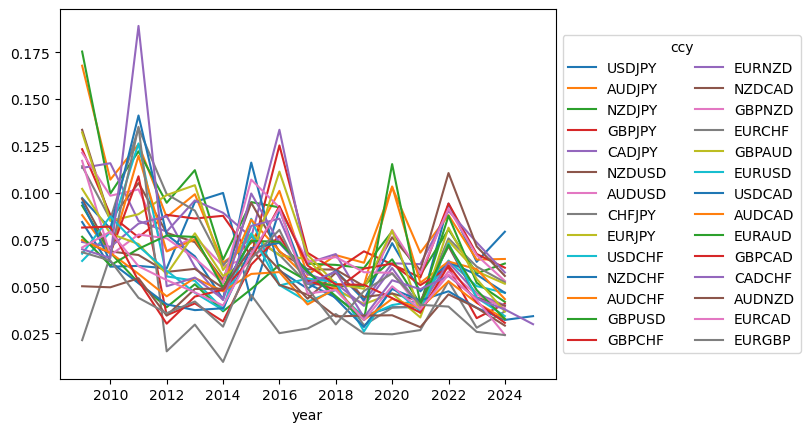

In [ ]:
# summary.xs('AUDUSD')[['gap_cnt']].plot()


wide = summarywy.xs(200, level=1)['gap_q75'].unstack('ccy')   # index = k, columns = ccy

# # Choose a sorting key: last available value per ccy
last_vals = wide.ffill().iloc[-1]          # forward-fill, then take the last row
order = last_vals.sort_values(ascending=False).index  # largest on top, smallest last (bottom)
ax = wide[order].plot(linewidth=1.5)
ax.legend(title='ccy', ncol=2, loc='center left', bbox_to_anchor=(1.0, 0.5))             # tweak layout as you like



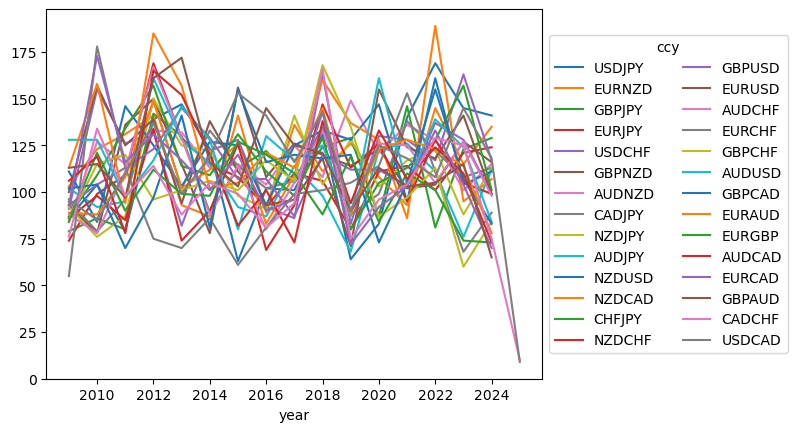

In [ ]:
wide = summarywy.xs(200, level=1)['gap_cnt'].unstack('ccy')   # index = k, columns = ccy

# # Choose a sorting key: last available value per ccy
last_vals = wide.ffill().iloc[-1]          # forward-fill, then take the last row
order = last_vals.sort_values(ascending=False).index  # largest on top, smallest last (bottom)
ax = wide[order].plot(linewidth=1.5)
ax.legend(title='ccy', ncol=2, loc='center left', bbox_to_anchor=(1.0, 0.5))             # tweak layout as you like


Summary Window

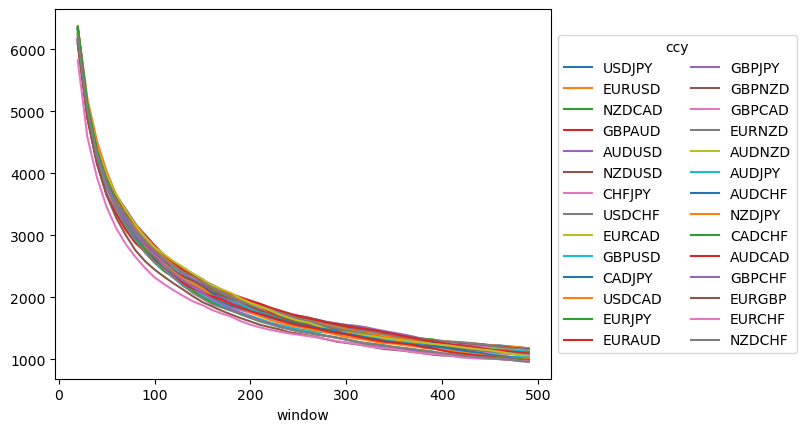

In [ ]:
wide = summaryw['gap_cnt'].unstack('ccy')   # index = k, columns = ccy

# # Choose a sorting key: last available value per ccy
last_vals = wide.ffill().iloc[-1]          # forward-fill, then take the last row
order = last_vals.sort_values(ascending=False).index  # largest on top, smallest last (bottom)
ax = wide[order].plot(linewidth=1.5)
ax.legend(title='ccy', ncol=2, loc='center left', bbox_to_anchor=(1.0, 0.5))             # tweak layout as you like


In [ ]:
wide = summaryw['gap_cnt'].unstack('ccy')   # index = k, columns = ccy

# # Choose a sorting key: last available value per ccy
last_vals = wide.ffill().iloc[-1]          # forward-fill, then take the last row
order = last_vals.sort_values(ascending=False).index  # largest on top, smallest last (bottom)
ax = wide[order].plot(linewidth=1.5)
ax.legend(title='ccy', ncol=2, loc='center left', bbox_to_anchor=(1.0, 0.5))             # tweak layout as you like


Analysis starts from here


In [117]:
%cd /home/ytee/test/trade_bot/
import pandas as pd
df =pd.read_csv('momentum_all_summary.csv')

/home/yteevm/.local/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/ytee/test/trade_bot


In [118]:
def generate_pivot(thresh, ratio, window, overlap, target):
    df2 = df[(df.thresh==thresh) & (df.window==window) &(df.ratio==ratio) & (df.overlap==overlap)]

    wide = df2.pivot(index='barrier_window', columns='ccy', values=target)
    # # Choose a sorting key: last available value per ccy
    last_vals = wide.ffill().iloc[-1]          # forward-fill, then take the last row
    order = last_vals.sort_values(ascending=False).index  # largest on top, smallest last (bottom)
    ax = wide[order].plot(linewidth=1.5)
    ax.legend(title='ccy', ncol=2, loc='center left', bbox_to_anchor=(1.0, 0.5))            


def generate_pivot_table(thresh, ratio, overlap, target, idx,  col):
    df2 = df[(df.thresh==thresh)  &(df.ratio==ratio) & (df.overlap==overlap)]
    wide = df2.pivot_table(index=idx, columns=col, values=target , aggfunc='mean')
    ax = wide.plot()
    ax.legend(title=col, ncol=2, loc='center left', bbox_to_anchor=(1.0, 0.5))    


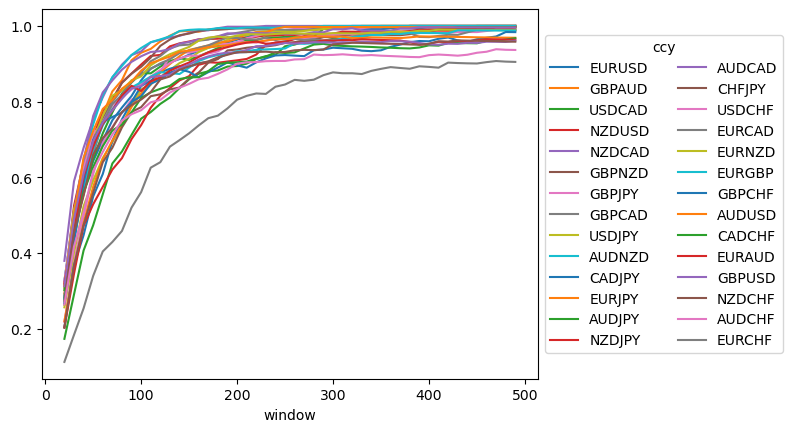

In [122]:
thresh = 'gap_q25'
ratio = 1
barrier_window=20
overlap=0
df2 = df[(df.thresh==thresh) & (df.ratio==ratio) & (df.barrier_window==barrier_window) & (df.overlap==overlap)]
wide = df2.pivot(index='window', columns='ccy', values='none_gt75')
# # Choose a sorting key: last available value per ccy
last_vals = wide.ffill().iloc[-1]          # forward-fill, then take the last row
order = last_vals.sort_values(ascending=False).index  # largest on top, smallest last (bottom)
ax = wide[order].plot(linewidth=1.5)
ax.legend(title='ccy', ncol=2, loc='center left', bbox_to_anchor=(1.0, 0.5))            


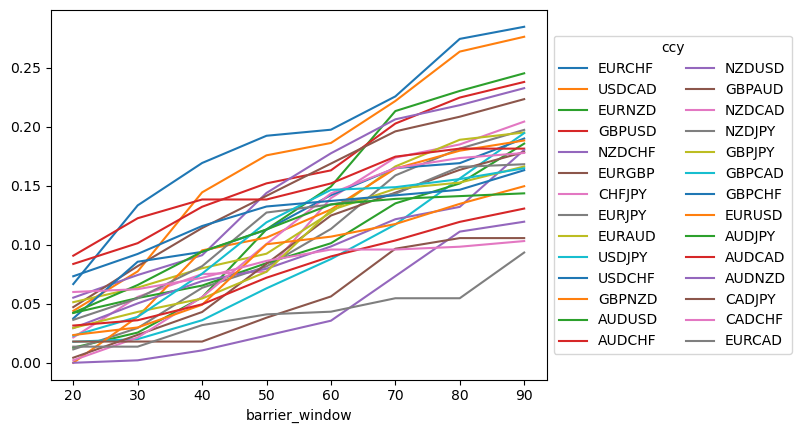

In [64]:
thresh = 'gap_q75'
ratio = 0.5
window=200
overlap=0
target = 'tp_gt75'
generate_pivot(thresh, ratio, window, overlap, target)



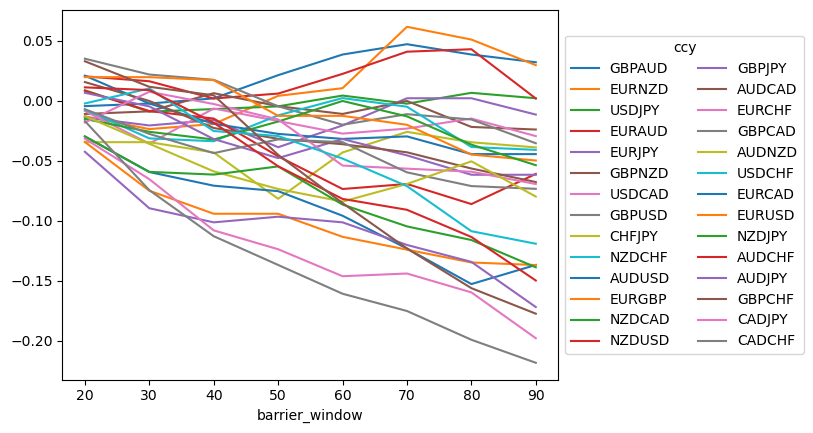

In [74]:
thresh = 'gap_q75'
ratio = 0.5
window=200
overlap=0
target = 'gt75'
generate_pivot(thresh, ratio, window, overlap, target)


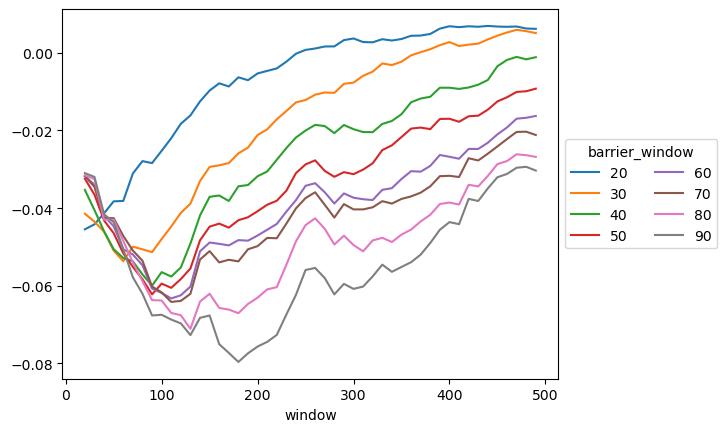

In [99]:
thresh = 'gap_q75'
ratio = 0.5
overlap=0
target = 'gt75'
generate_pivot_table(thresh, ratio,  overlap, target, 'window', 'barrier_window')


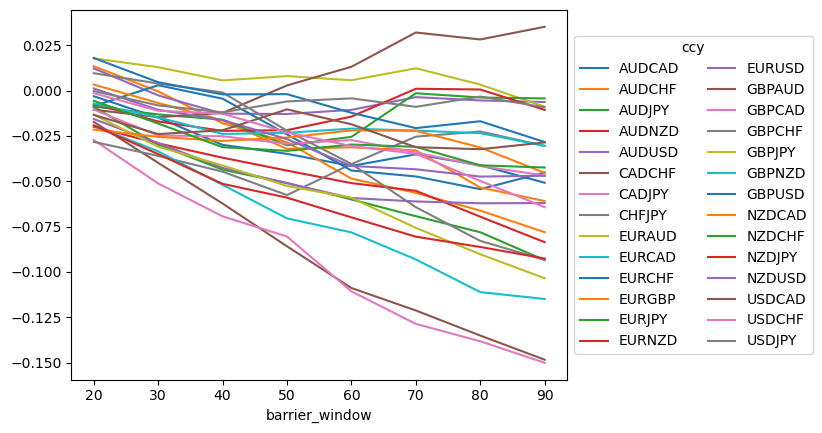

In [101]:
thresh = 'gap_q75'
ratio = 0.5
overlap=0
target = 'gt75'
generate_pivot_table(thresh, ratio,  overlap, target, 'barrier_window', 'ccy')

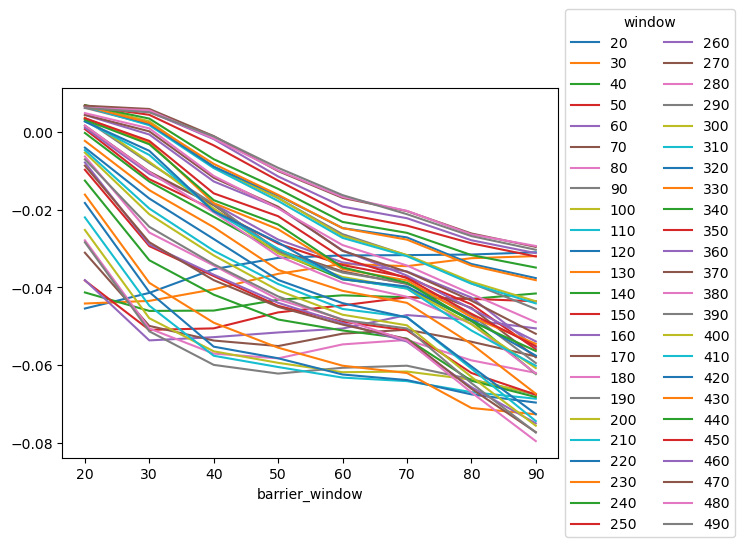

In [102]:
thresh = 'gap_q75'
ratio = 0.5
overlap=0
target = 'gt75'
generate_pivot_table(thresh, ratio,  overlap, target, 'barrier_window', 'window')

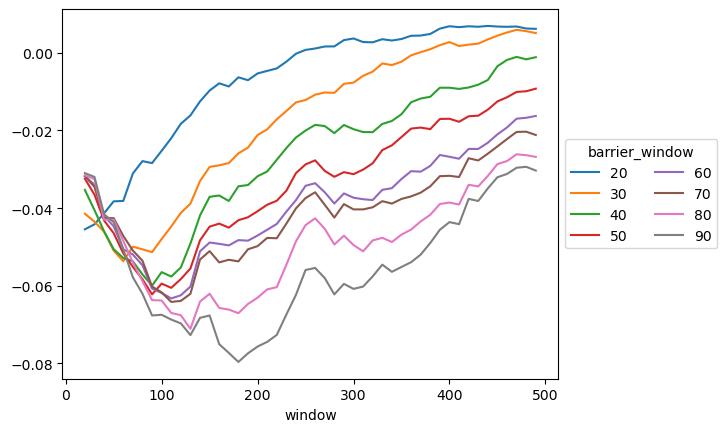

In [105]:
thresh = 'gap_q75'
ratio = 0.5
overlap=0
target = 'gt75'
generate_pivot_table(thresh, ratio,  overlap, target, 'window', 'barrier_window')